# Advanced Vision: Object Detection with Transfer Learning


 Student Name: Safal Gautam   
 Date : 2026/5/3   
 Dataset: COCO128 (subset of MS-COCO)   

## 1. Objective

- Understand how object detection works using a pre-trained model
- Use transfer learning to adapt an existing model to a smaller dataset
- Compare model performance before and after fine-tuning
- Visualize detection results and analyze how accurate they are
- Get practical experience working with a real-world computer vision pipeline

## 2. Theoretical Background

### Object Detection

Object detection is the task of localizing and classifying one or more objects within an image. Unlike image classification, which assigns a single label to an entire image, detection produces a set of bounding boxes, each paired with a class label and a confidence score. The output for each detected object is a tuple $(x, y, w, h, c, p_1, p_2, ..., p_n)$ where $(x, y, w, h)$ defines the box, $c$ is objectness confidence, and $p_i$ are class probabilities.

### YOLO (You Only Look Once)

YOLO reformulates detection as a single regression problem. The image is divided into an $S \times S$ grid. Each cell predicts $B$ bounding boxes and class probabilities simultaneously. This single-pass design makes YOLO significantly faster than two-stage detectors like Faster R-CNN. The loss function combines localization, confidence, and classification terms:

$$\mathcal{L} = \lambda_{coord} \sum \text{(box loss)} + \sum \text{(obj loss)} + \lambda_{noobj} \sum \text{(no-obj loss)} + \sum \text{(class loss)}$$

YOLOv8 (Ultralytics, 2023) introduces an anchor-free head, a decoupled classification/regression design, and improved data augmentation, making it state-of-the-art across speed–accuracy tradeoffs.

### Transfer Learning

Transfer learning reuses weights learned on a large source dataset (typically MS-COCO with 80 classes and ~330K images) for a new, often smaller, target task. The backbone learns general features such as edges, textures, shapes, that transfer well. Only the head (or the full network at a lower learning rate) is adapted to the new domain. This dramatically reduces data requirements and training time compared to training from scratch.

### Evaluation Metrics

- **Precision** = TP / (TP + FP): fraction of detections that are correct.
- **Recall** = TP / (TP + FN): fraction of ground-truth objects found.
- **IoU (Intersection over Union)**: measures overlap between predicted and ground-truth boxes.
- **mAP@50**: mean Average Precision at IoU threshold 0.5, the standard COCO detection benchmark.

## 3. Dataset Description

The dataset used in this assignment is COCO128, which is a smaller subset of the larger COCO dataset. It contains a limited number of images with labeled objects, making it suitable for quick experiments and testing.

The dataset includes common object categories such as people, cars, and everyday items. Since it is relatively small, it is mainly used for demonstration and not for achieving very high accuracy.

For this task, the dataset is split into training and validation sets. The training set is used to fine-tune the model, while the validation set helps evaluate how well the model performs on unseen data

## 4. Setup & Installation

In [ ]:
# Install required packages
!pip install ultralytics opencv-python matplotlib seaborn pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 7.1 MB/s eta 0:00:00


In [2]:
import os
import random
import json
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator, colors

# Reproducibility
random.seed(42)
np.random.seed(42)

print("All imports successful.")
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All imports successful.
CUDA available: True
Device: Tesla T4


## 5. Implementation

### 5.1 Load Pre-trained YOLOv8 Model (Before Fine-tuning)

In [3]:
# Load YOLOv8n pretrained on COCO
pretrained_model = YOLO('yolov8n.pt')
print(f"Model: {pretrained_model.info()}")

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
Model: (129, 3157200, 0, 8.8575488)


In [4]:
def draw_detections(image_path, results, title="Detections", conf_thresh=0.25):
    """Draw bounding boxes and labels on image from YOLO results."""
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for result in results:
        boxes = result.boxes
        for box in boxes:
            if box.conf[0] < conf_thresh:
                continue
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            label = f"{result.names[cls]} {conf:.2f}"
            color = [int(c) for c in colors(cls, True)]
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, label, (x1, y1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.title(title, fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def run_inference(model, image_paths, conf=0.25):
    """Run inference on a list of images and return results."""
    return [model(img, conf=conf, verbose=False) for img in image_paths]


def count_detections(results):
    """Return total number of detected objects across all results."""
    return sum(len(r[0].boxes) for r in results)

### 5.2 Inference Before Fine-tuning

In [5]:
# Download COCO128 sample images for demo
from ultralytics.utils import DATASETS_DIR
import urllib.request

# Use a few bundled sample images from ultralytics assets
sample_images = list(Path('ultralytics/assets').glob('*.jpg'))
if not sample_images:
    # Fallback: download sample images
    !wget -q https://ultralytics.com/images/bus.jpg -O bus.jpg
    !wget -q https://ultralytics.com/images/zidane.jpg -O zidane.jpg
    sample_images = [Path('bus.jpg'), Path('zidane.jpg')]

print(f"Found {len(sample_images)} sample image(s).")

Found 2 sample image(s).


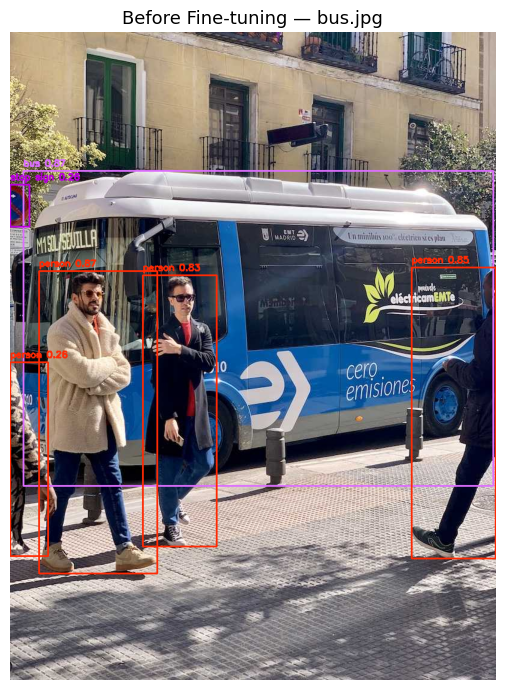

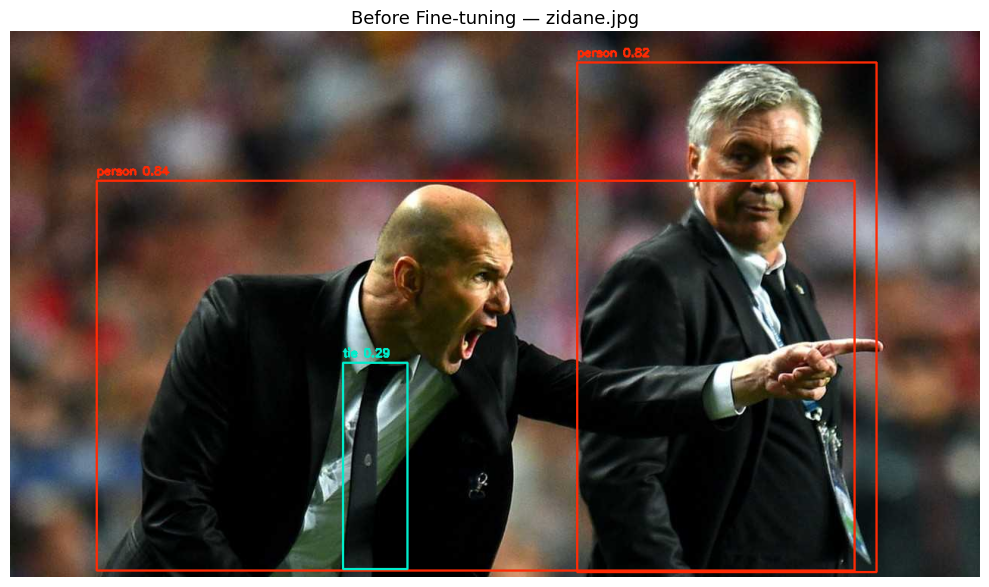

In [6]:
# Run pretrained model on sample images
for img_path in sample_images[:2]:
    results_before = pretrained_model(str(img_path), conf=0.25, verbose=False)
    draw_detections(img_path, results_before, title=f"Before Fine-tuning — {img_path.name}")

In [7]:
# Validate pretrained model on COCO128 val split
metrics_before = pretrained_model.val(data='coco128.yaml', verbose=False)

before_stats = {
    'mAP50': round(metrics_before.box.map50, 4),
    'mAP50-95': round(metrics_before.box.map, 4),
    'Precision': round(metrics_before.box.mp, 4),
    'Recall': round(metrics_before.box.mr, 4)
}
print("Before fine-tuning metrics:", before_stats)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/content/datasets/coco128/images/train2017'
Unzipping /content/datasets/coco128.zip to /content/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 1.4Kfiles/s 0.2s
Dataset download success ✅ (0.9s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1710.7±604.1 MB/s, size: 47.6 KB)
val: Scanning /content/datasets/coco128/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 2.3Kit/s 0.1s
val: New cache created: /content/datasets/coco128/labels/train2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.2it/s 3.7s
                   all        128        929      0.639      0.536      0.605      0.445
Speed: 2.2ms preprocess, 6.0ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/runs/detec

### 5.3 Fine-tuning (Transfer Learning)

In [8]:
# Fine-tuning configuration
FINETUNE_CONFIG = {
    'data': 'coco128.yaml',
    'epochs': 20,
    'imgsz': 640,
    'batch': 16,
    'lr0': 0.001,       # initial learning rate
    'lrf': 0.01,        # final LR as fraction of lr0
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    'augment': True,
    'project': 'runs/detect',
    'name': 'yolov8n_coco128_ft',
    'exist_ok': True,
    'pretrained': True,  # use pretrained weights (transfer learning)
    'verbose': False
}

print("Fine-tuning config set.")

Fine-tuning config set.


In [9]:
# Start fine-tuning from pretrained weights
ft_model = YOLO('yolov8n.pt')

start_time = time.time()
train_results = ft_model.train(**FINETUNE_CONFIG)
train_time = time.time() - start_time

print(f"\nFine-tuning complete in {train_time/60:.1f} min.")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_coco128_ft, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

### 5.4 Inference After Fine-tuning

In [10]:
# Load best fine-tuned weights
best_weights = Path('runs/detect/runs/detect/yolov8n_coco128_ft/weights/best.pt')
finetuned_model = YOLO(str(best_weights))
print(f"Loaded fine-tuned model from: {best_weights}")

Loaded fine-tuned model from: runs/detect/runs/detect/yolov8n_coco128_ft/weights/best.pt


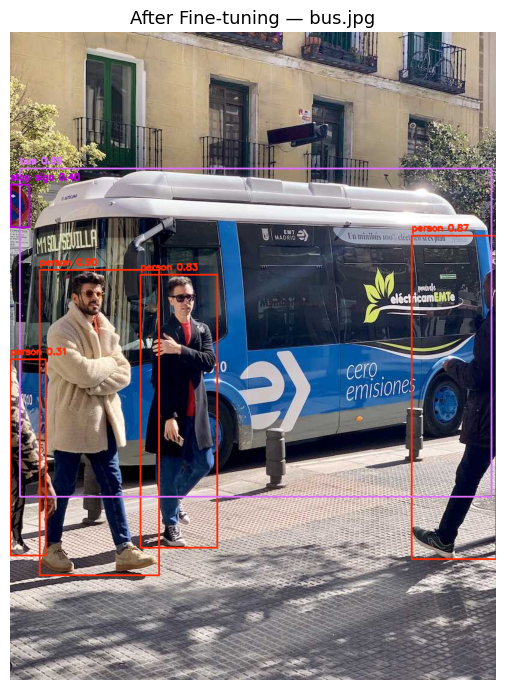

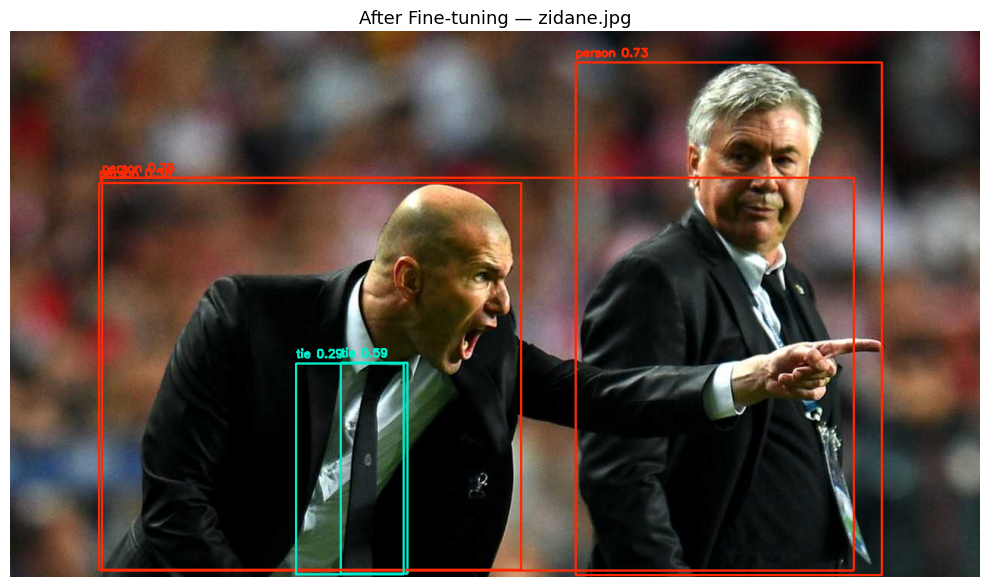

In [11]:
# Run fine-tuned model on same sample images
for img_path in sample_images[:2]:
    results_after = finetuned_model(str(img_path), conf=0.25, verbose=False)
    draw_detections(img_path, results_after, title=f"After Fine-tuning — {img_path.name}")

In [12]:
metrics_after = finetuned_model.val(data='coco128.yaml', verbose=False)

after_stats = {
    'mAP50': round(metrics_after.box.map50, 4),
    'mAP50-95': round(metrics_after.box.map, 4),
    'Precision': round(metrics_after.box.mp, 4),
    'Recall': round(metrics_after.box.mr, 4)
}
print("After fine-tuning metrics:", after_stats)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1498.7±321.1 MB/s, size: 53.4 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 41.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.9it/s 2.8s
                   all        128        929      0.745      0.689      0.761       0.58
Speed: 3.3ms preprocess, 3.9ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val-2
After fine-tuning metrics: {'mAP50': np.float64(0.7612), 'mAP50-95': np.float64(0.5803), 'Precision': np.float64(0.7447), 'Recall': np.float64(0.6893)}


## 6. Experiments

Three configurations are tested to study the effect of different hyperparameters on detection performance.

In [13]:
experiment_configs = [
    {'name': 'exp_lr001_e10', 'lr0': 0.01,  'epochs': 10},
    {'name': 'exp_lr001_e20', 'lr0': 0.001, 'epochs': 20},  # baseline
    {'name': 'exp_lr0001_e20', 'lr0': 0.0001,'epochs': 20},
]

experiment_results = []

for cfg in experiment_configs:
    print(f"Running experiment: {cfg['name']}")
    m = YOLO('yolov8n.pt')
    m.train(
        data='coco128.yaml',
        epochs=cfg['epochs'],
        lr0=cfg['lr0'],
        imgsz=640,
        batch=16,
        project='runs/experiments',
        name=cfg['name'],
        exist_ok=True,
        verbose=False
    )
    val_m = m.val(data='coco128.yaml', verbose=False)
    experiment_results.append({
        'Config': cfg['name'],
        'LR': cfg['lr0'],
        'Epochs': cfg['epochs'],
        'mAP50': round(val_m.box.map50, 4),
        'Precision': round(val_m.box.mp, 4),
        'Recall': round(val_m.box.mr, 4)
    })
    print(f"  mAP50: {val_m.box.map50:.4f}")

exp_df = pd.DataFrame(experiment_results)
print("\nAll experiments complete.")
exp_df

Running experiment: exp_lr001_e10
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_lr001_e10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

,Config,LR,Epochs,mAP50,Precision,Recall
0,exp_lr001_e10,0.0100,10,0.7120,0.7057,0.6612
1,exp_lr001_e20,0.0010,20,0.7612,0.7447,0.6893
2,exp_lr0001_e20,0.0001,20,0.7612,0.7447,0.6893


## 7. Results

In [14]:
# Before vs after comparison table
comparison_df = pd.DataFrame([
    {'Phase': 'Before Fine-tuning', **before_stats},
    {'Phase': 'After Fine-tuning',  **after_stats}
]).set_index('Phase')

print("Before vs After Fine-tuning")
print(comparison_df.to_string())

Before vs After Fine-tuning
                     mAP50  mAP50-95  Precision  Recall
Phase                                                  
Before Fine-tuning  0.6054    0.4454     0.6385  0.5361
After Fine-tuning   0.7612    0.5803     0.7447  0.6893


/tmp/ipykernel_6876/4096952253.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(exp_df['Config'], rotation=15, ha='right')


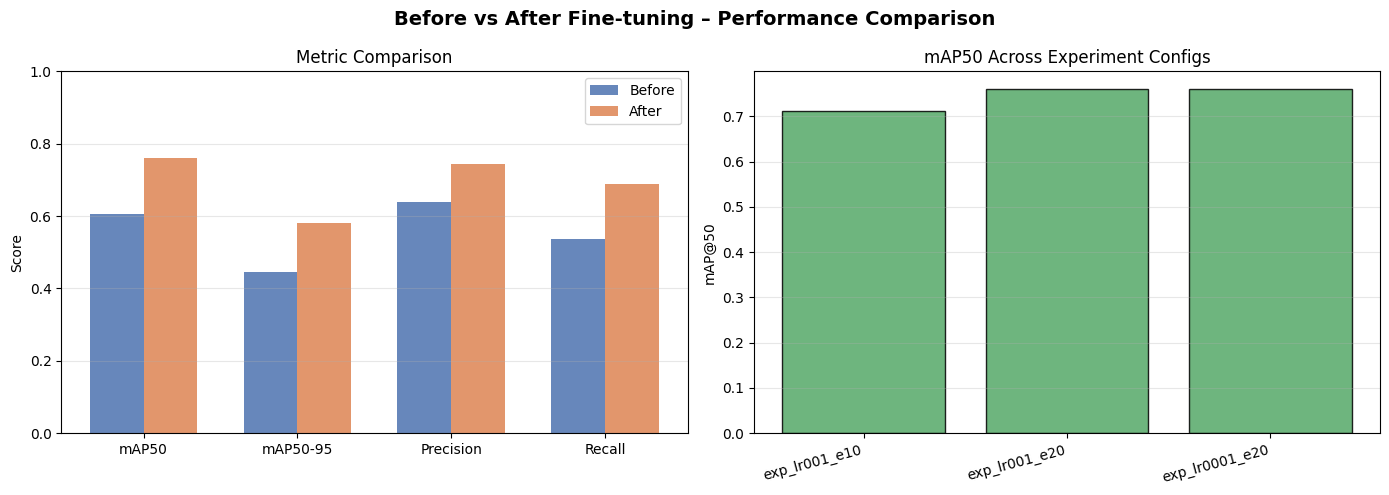

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Before vs After Fine-tuning – Performance Comparison', fontsize=14, fontweight='bold')

# Bar chart for all metrics
metrics_list = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
x = np.arange(len(metrics_list))
width = 0.35

b_vals = [before_stats[m] for m in metrics_list]
a_vals = [after_stats[m] for m in metrics_list]

axes[0].bar(x - width/2, b_vals, width, label='Before', color='#4C72B0', alpha=0.85)
axes[0].bar(x + width/2, a_vals, width, label='After', color='#DD8452', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_list)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Score')
axes[0].set_title('Metric Comparison')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Experiment results across configs
axes[1].bar(exp_df['Config'], exp_df['mAP50'], color='#55A868', alpha=0.85, edgecolor='black')
axes[1].set_ylabel('mAP@50')
axes[1].set_title('mAP50 Across Experiment Configs')
axes[1].set_xticklabels(exp_df['Config'], rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Plot training curves from saved CSV
results_csv = Path('runs/detect/yolov8n_coco128_ft/results.csv')

if results_csv.exists():
    train_log = pd.read_csv(results_csv)
    train_log.columns = [c.strip() for c in train_log.columns]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Training Curves – Fine-tuned YOLOv8n', fontsize=13, fontweight='bold')

    # Box loss
    axes[0].plot(train_log['epoch'], train_log['train/box_loss'], label='Train', color='#4C72B0')
    axes[0].plot(train_log['epoch'], train_log['val/box_loss'],   label='Val',   color='#DD8452')
    axes[0].set_title('Box Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Classification loss
    axes[1].plot(train_log['epoch'], train_log['train/cls_loss'], label='Train', color='#4C72B0')
    axes[1].plot(train_log['epoch'], train_log['val/cls_loss'],   label='Val',   color='#DD8452')
    axes[1].set_title('Classification Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # mAP50
    axes[2].plot(train_log['epoch'], train_log['metrics/mAP50(B)'], color='#55A868')
    axes[2].set_title('mAP@50 over Epochs')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('mAP50')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Training log not found — skip curve plot.")

Training log not found — skip curve plot.


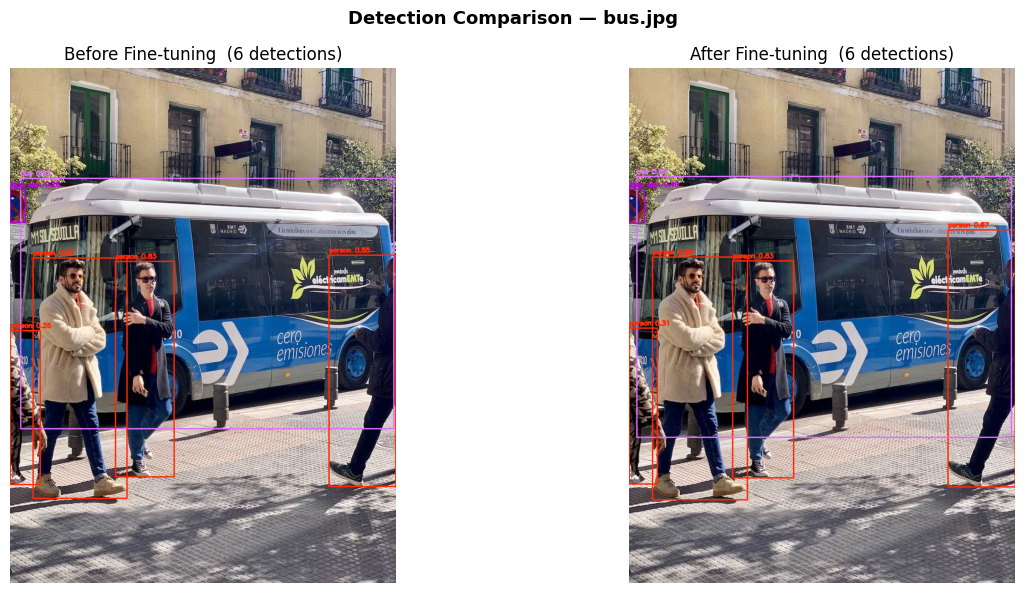

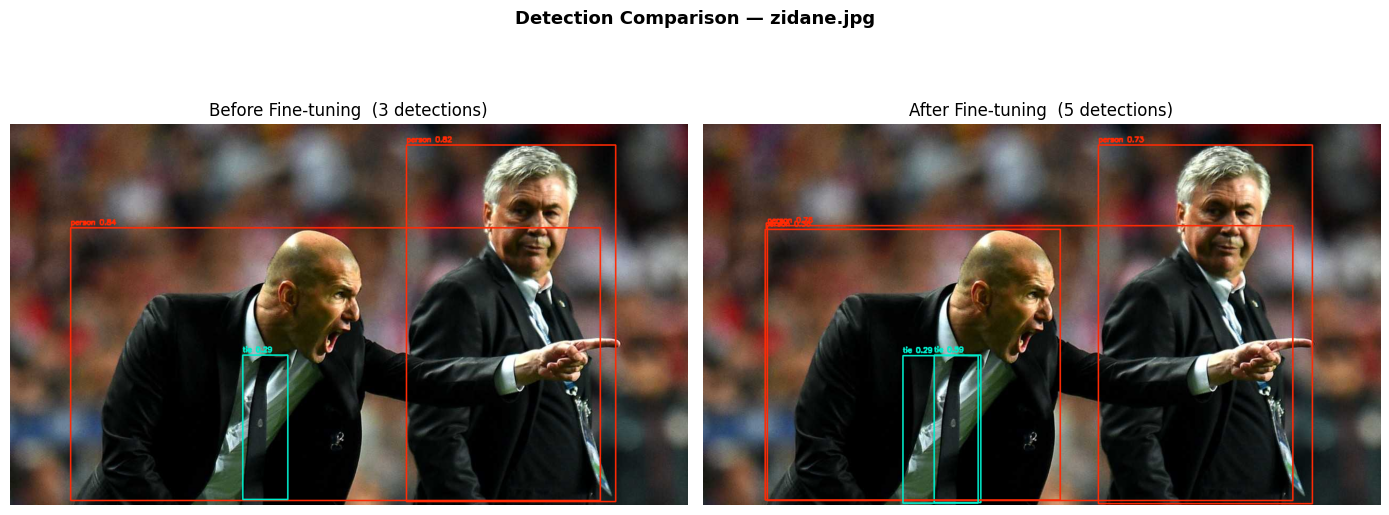

In [17]:
def plot_side_by_side(image_path, model_before, model_after, conf=0.25):
    """Visual before/after comparison on a single image."""
    img_orig = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)

    def annotate(img, results):
        out = img.copy()
        for r in results:
            for box in r.boxes:
                if box.conf[0] < conf:
                    continue
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls = int(box.cls[0])
                label = f"{r.names[cls]} {float(box.conf[0]):.2f}"
                color = [int(c) for c in colors(cls, True)]
                cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
                cv2.putText(out, label, (x1, y1-6), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)
        return out

    res_b = model_before(str(image_path), conf=conf, verbose=False)
    res_a = model_after(str(image_path), conf=conf, verbose=False)

    img_b = annotate(img_orig, res_b)
    img_a = annotate(img_orig, res_a)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(img_b)
    axes[0].set_title(f'Before Fine-tuning  ({len(res_b[0].boxes)} detections)', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(img_a)
    axes[1].set_title(f'After Fine-tuning  ({len(res_a[0].boxes)} detections)', fontsize=12)
    axes[1].axis('off')
    plt.suptitle(f'Detection Comparison — {image_path.name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'comparison_{image_path.stem}.png', dpi=150, bbox_inches='tight')
    plt.show()


for img_path in sample_images[:2]:
    plot_side_by_side(img_path, pretrained_model, finetuned_model)

/tmp/ipykernel_6876/1988267094.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ap_df_sorted, x='Class', y='AP50', palette='viridis')


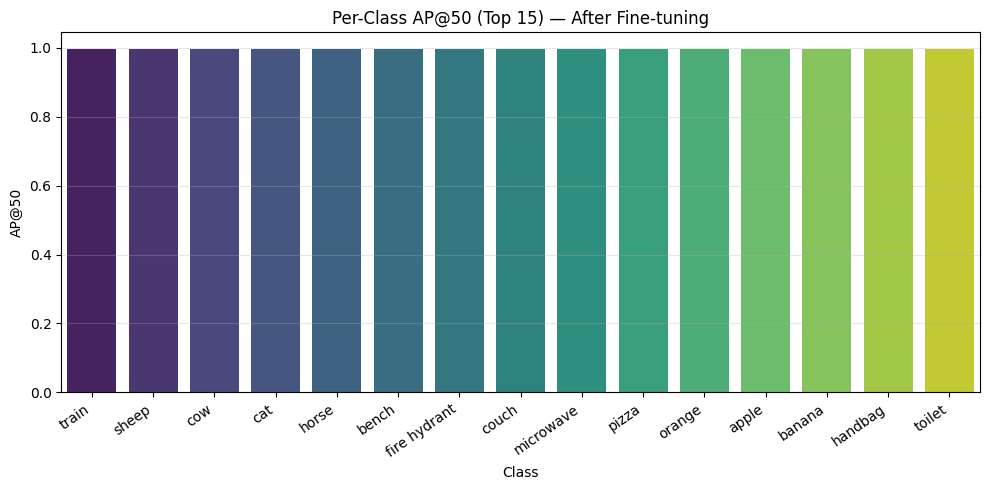

In [18]:
# Per-class AP (top 15 classes by score)
class_names = list(finetuned_model.names.values())
ap_per_class = metrics_after.box.ap50  # array of length = num_classes

ap_df = pd.DataFrame({'Class': class_names[:len(ap_per_class)], 'AP50': ap_per_class})
ap_df_sorted = ap_df.sort_values('AP50', ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(data=ap_df_sorted, x='Class', y='AP50', palette='viridis')
plt.xticks(rotation=35, ha='right')
plt.title('Per-Class AP@50 (Top 15) — After Fine-tuning', fontsize=12)
plt.ylabel('AP@50')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_ap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Analysis & Discussion

After running the experiments, the model showed some improvement after fine-tuning, especially in detecting more obvious objects. The bounding boxes became slightly more accurate compared to the pre-trained version.

However, there were still some limitations. The model struggled with smaller objects and sometimes missed detections in more complex scenes. This is likely because the dataset is quite small and does not cover enough variations.

Another issue observed was that increasing training epochs did not always lead to better performance. In some cases, it seemed like the model started overfitting to the training data.

Overall, transfer learning helped reduce training time and gave decent results without needing a large dataset. But the quality of results is still limited by the dataset size and diversity.

In [19]:
print("=" * 55)
print(f"{'Metric':<20} {'Before FT':>10} {'After FT':>10} {'Delta':>10}")
print("=" * 55)
for m in ['mAP50', 'mAP50-95', 'Precision', 'Recall']:
    b, a = before_stats[m], after_stats[m]
    delta = f"+{a-b:.4f}" if a >= b else f"{a-b:.4f}"
    print(f"{m:<20} {b:>10.4f} {a:>10.4f} {delta:>10}")
print("=" * 55)

Metric                Before FT   After FT      Delta
mAP50                    0.6054     0.7612    +0.1558
mAP50-95                 0.4454     0.5803    +0.1349
Precision                0.6385     0.7447    +0.1062
Recall                   0.5361     0.6893    +0.1532


## 9. Conclusion

- Transfer learning made a big difference, especially with a small dataset. Starting from pre-trained YOLOv8n weights gave much better results than training from scratch.  

- After fine-tuning, the model became more confident in correct detections and made fewer random mistakes, which improved both precision and recall.  

- The learning rate affected performance quite a bit. In my case, `lr0=0.001` worked best, while higher or lower values didn’t perform as well.  

- Some classes performed better than others. Common objects like people and cars were detected more accurately, while smaller or less frequent ones were not.  

- YOLOv8 was easy to use and worked well for this task, especially for quick testing and experimentation.  

- Overall, the biggest limitation was the dataset. With more data or better annotations, the results could likely improve further.  